### Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

In [2]:
# Load the dataset
df = pd.read_csv("sales_data_with_discounts.csv")

# Display first five rows
print(df.head())

         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [4]:
# Identify Numerical Columns

numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


In [5]:
# Mean
print(df[numerical_columns].mean())

Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64


In [6]:
# Median

print(df[numerical_columns].median())

Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64


In [7]:
# Mode

print(df[numerical_columns].mode())

     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0       3.0      400.0            24300.0           5.007822        69.177942   
1       NaN      450.0                NaN           5.055218        73.025199   
2       NaN      500.0                NaN           5.059801        93.649161   
3       NaN     1300.0                NaN           5.072124        94.682735   
4       NaN     8100.0                NaN           5.084108       102.705757   
..      ...        ...                ...                ...              ...   
445     NaN        NaN                NaN          19.940610     17900.983733   
446     NaN        NaN                NaN          19.965340     21153.498820   
447     NaN        NaN                NaN          19.976879     21496.675367   
448     NaN        NaN                NaN          19.982257     25328.224204   
449     NaN        NaN                NaN          19.992407     25738.022194   

     Net Sales Value  
0   

In [8]:
# Standard Deviation

print(df[numerical_columns].std())

Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


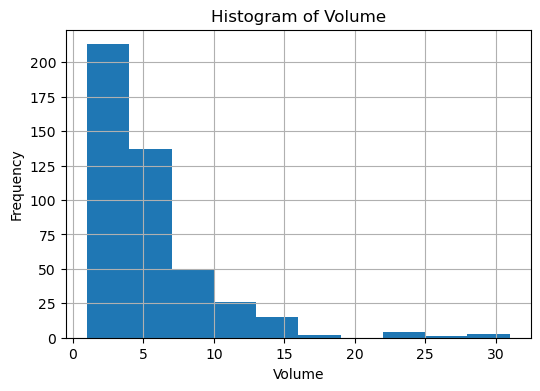

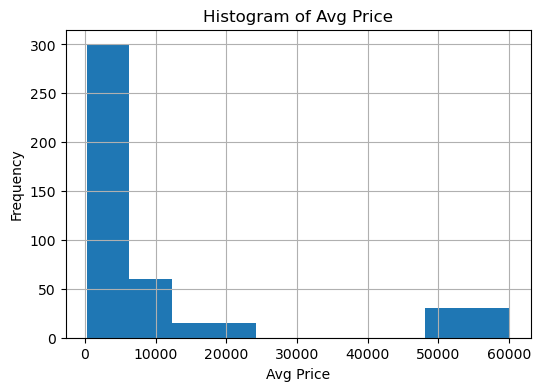

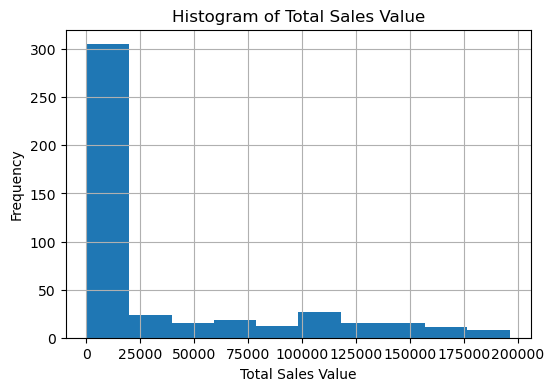

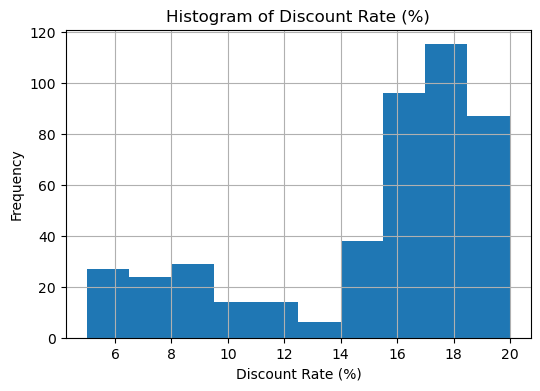

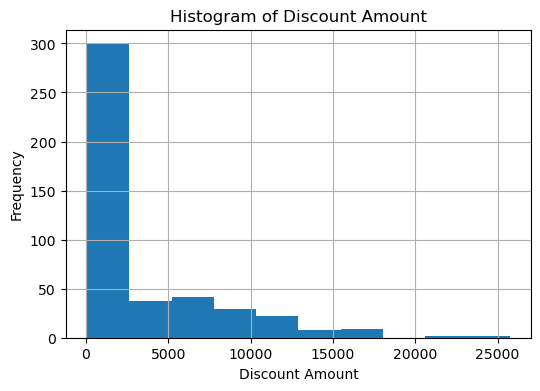

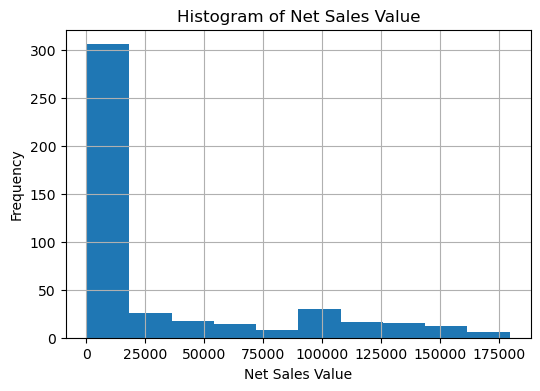

In [9]:
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column].dropna(), bins=10)
    plt.title("Histogram of "+column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

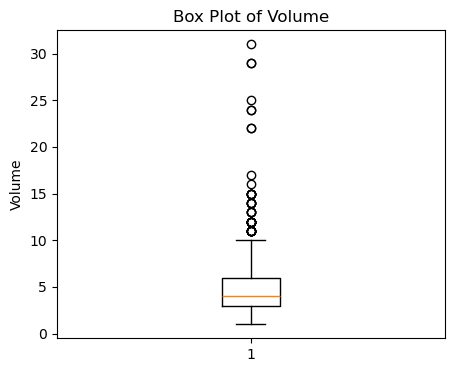

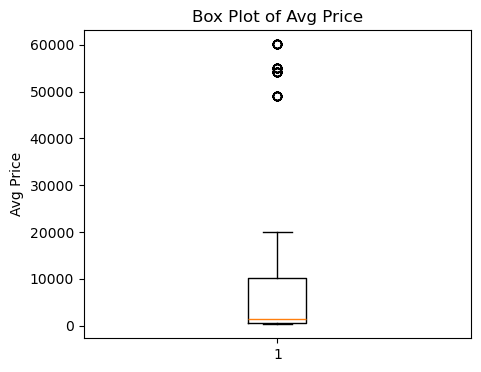

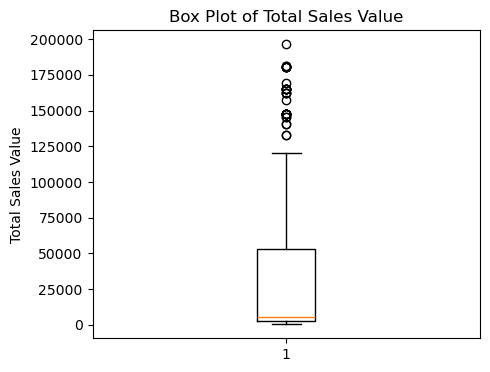

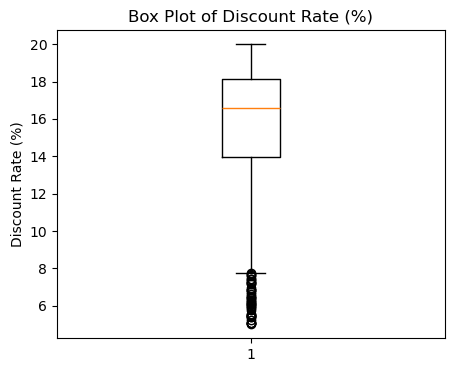

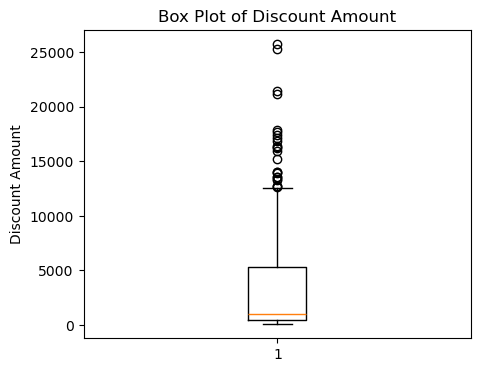

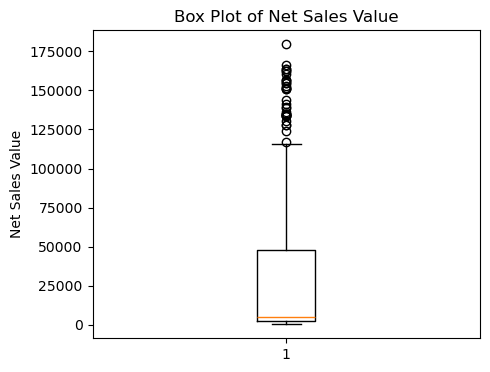

In [10]:
for column in numerical_columns:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[column])
    plt.title("Box Plot of " + column)
    plt.ylabel(column)
    plt.show()

In [11]:
categorical_columns = df.select_dtypes(include="object").columns
print(categorical_columns)

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


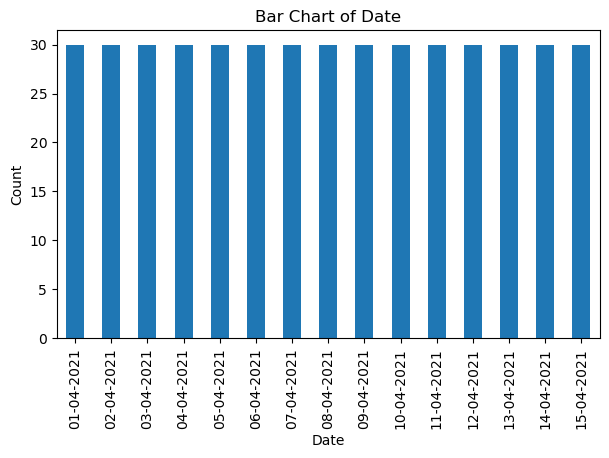

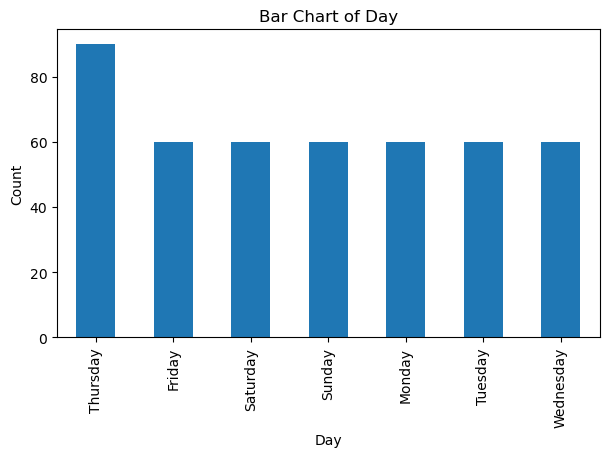

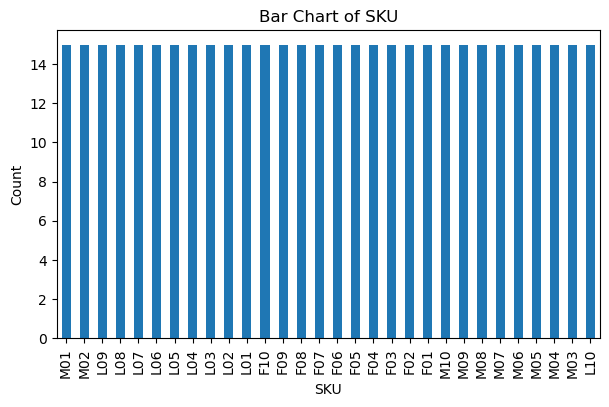

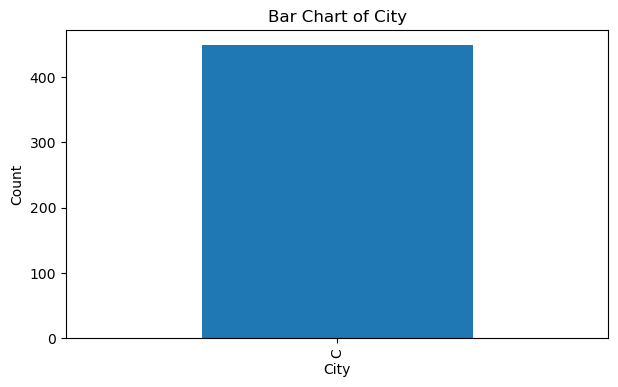

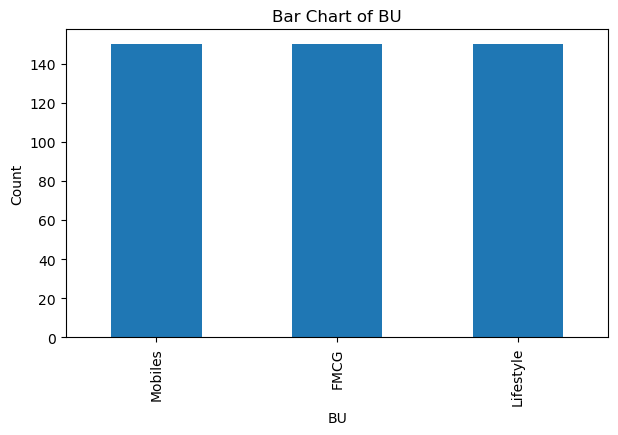

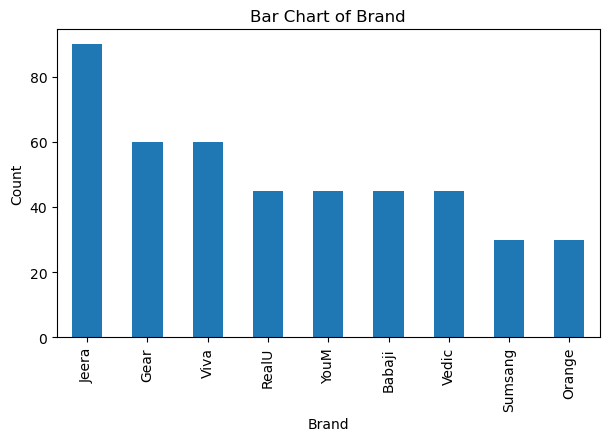

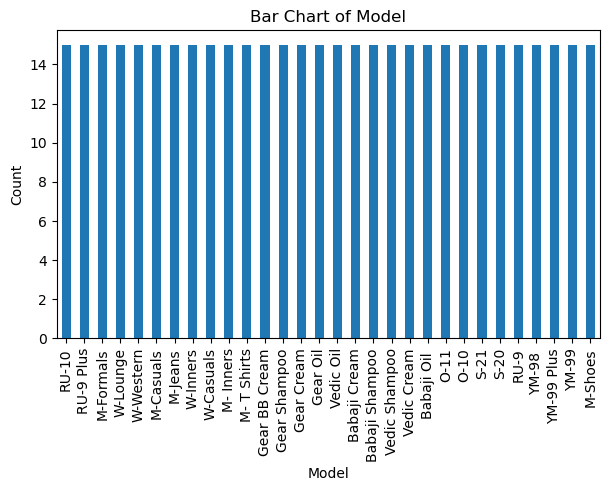

In [12]:
for column in categorical_columns:
    plt.figure(figsize=(7,4))
    df[column].value_counts().plot(kind="bar")
    plt.title("Bar Chart of "+ column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

In [13]:
print(df.isnull().sum())

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64


### Fill Missing Values

In [14]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].mean())

print(df.isnull().sum())


Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64


### Remove duplicate Rows

In [15]:
df = df.drop_duplicates()

print("Shape after removing duplicates: ")
print(df.shape)

Shape after removing duplicates: 
(450, 13)


## Conclusion

The sales and discounts dataset was successfully analyzed using descriptive statistics and data visualization techniques. The numerical variables were analyzed using measures such as mean, median, mode, and standard deviation to understand their distribution and variability. Histograms and boxplots helped identify the distribution of the data and any potential outliers, while bar charts provided insights into the categorical variables. The dataset was also checked for missing values and duplicate records, and the required preprocessing steps were performed. Overall, the analysis provided a clear understanding of the dataset and highlighted important patterns and characteristics of the sales and discount data.